Some import needed for later and base function used later

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "True"

import numpy as np
import matplotlib.pyplot as plt
import copy
import random
import torch
from torch.utils.data import DataLoader, Subset
import torch.nn as nn

from src_base.AudioMnist import AudioMNIST 
from src_base.base_cnn import BaseCNN  
from src_base.Federated import Client, FedAvg 

# Collate function for AudioMNIST
def collate_fn(batch):
    '''Properly formats batches for AudioMNIST'''
    data, labels = zip(*batch)
    data = torch.stack([d.squeeze() for d in data]).unsqueeze(1)  # [batch, 1, 8000]
    digit_labels = torch.tensor([l.squeeze()[0].item() for l in labels])
    return data, digit_labels


Load Data

In [2]:
batch_size = 16

# Load train dataset
train_dataset = AudioMNIST(
    root='./preprocessed_data',
    model_type='AudioNet',
    task='digit',
    split=0,
    mode='train'
)

# Load validation dataset
val_dataset = AudioMNIST(
    root='./preprocessed_data',
    model_type='AudioNet',
    task='digit',
    split=0,
    mode='validate'
)

# Create validation loader
valloader = DataLoader(val_dataset, batch_size=batch_size,
                      shuffle=False, num_workers=0, collate_fn=collate_fn)

# Load test dataset
test_dataset = AudioMNIST(
    root='./preprocessed_data',
    model_type='AudioNet',
    task='digit',
    split=0,
    mode='test'
)

testloader = DataLoader(test_dataset, batch_size=batch_size,
                       shuffle=False, num_workers=0, collate_fn=collate_fn)

# Define digit classes
digits = ('0', '1', '2', '3', '4', '5', '6', '7', '8', '9')




In [3]:
# ==================== Initialize Model ====================
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

net = BaseCNN().to(device)

trainable_params = sum(p.numel() for p in net.parameters() if p.requires_grad)
print("Trainable parameters:", trainable_params)

init_weights = copy.deepcopy(net.state_dict())




device: cuda:0
device: cuda:0
Trainable parameters: 327434


In [4]:
# ==================== Federated Learning Setup ====================
# Check with one client to see the difference

NUM_CLIENTS = 5          # number of clients
IID_DATA = False         # whether the data is IID or not
NUM_ROUNDS = 15          # number of rounds of federated learning
NUM_LOCAL_EPOCHS = 1     # number of local epochs
C = 1.0                  # fraction of clients to use per round
CLIENTS_PER_ROUND = int(NUM_CLIENTS * C)
LR = 0.001               # learning rate
DATA_SIZE = len(train_dataset)


criterion = nn.CrossEntropyLoss()

def get_client_indices_by_speaker(dataset, num_clients):
    speaker_to_indices = {}
    
    for idx, filepath in enumerate(dataset.file_paths):
        speaker_id = os.path.basename(filepath).split('_')[2]
        
        if speaker_id not in speaker_to_indices:
            speaker_to_indices[speaker_id] = []
        speaker_to_indices[speaker_id].append(idx)
    
    unique_speakers = list(speaker_to_indices.keys())
    random.shuffle(unique_speakers)
    
    speaker_groups = torch.tensor_split(torch.tensor(range(len(unique_speakers))), num_clients)
    
    client_indices = []
    for group in speaker_groups:
        current_client_idx = []
        for s_idx in group:
            speaker_id = unique_speakers[s_idx]
            current_client_idx.extend(speaker_to_indices[speaker_id])
        client_indices.append(torch.tensor(current_client_idx))
        
    return client_indices


# Create indices for each client
if IID_DATA:
    client_indices = torch.tensor_split(torch.randperm(DATA_SIZE), NUM_CLIENTS)
else:
    client_indices = get_client_indices_by_speaker(train_dataset, NUM_CLIENTS)

# Create clients
clients = [
    Client(net=BaseCNN(input_size=8000, nb_class=10), 
           data=Subset(train_dataset, indices), 
           batch_size=batch_size, 
           criterion=criterion,
           collate_fn=collate_fn, 
           device=device, 
           LR=LR)
    for indices in client_indices
]

print(f"Samples per client: {len(client_indices[0]):d}")
print(f"Clients per round: {CLIENTS_PER_ROUND:d}")




device: cuda:0
device: cuda:0
device: cuda:0
device: cuda:0
device: cuda:0
Samples per client: 4000
Clients per round: 5


In [5]:
# ==================== Federated Training ====================
avg_test_loss = []
valid_accs = []

current_weights = copy.deepcopy(init_weights)

PERSONALIZED = ['fc2']

for round in range(NUM_ROUNDS):
    local_weights = []
    temp_avg_loss = 0 
    
    for id in range(NUM_CLIENTS):
        shared_weights = {k: v.cpu() for k, v in current_weights.items() 
                          if not any(p in k for p in PERSONALIZED)}
        
        state_dict, loss = clients[id].train_personnalized(NUM_LOCAL_EPOCHS, shared_weights)
        
        shared_weights_out = {k: v for k, v in state_dict.items() 
                         if not any(p in k for p in PERSONALIZED)}
        
        local_weights.append(shared_weights_out)
        temp_avg_loss += loss

    avg_test_loss.append(temp_avg_loss / len(client_indices))
    print(f"Round {round+1} loss: {avg_test_loss[-1]:.4f}")
    
    # Federated averaging
    new_weights = FedAvg(local_weights)
    print("Federated Averaging done")
    diff = {}

    #for key in shared_weights.keys():
    #    diff[key] = current_weights[key] - new_weights[key]
    #print(f"Update norm :{np.linalg.norm(diff)}")
    current_weights = new_weights
    

    # Validation

    correct = 0
    total = 0
    
    for id in range(NUM_CLIENTS):
        shared_weights = {k: v for k, v in current_weights.items() 
                          if not any(p in k for p in PERSONALIZED)}
        client_net = clients[id].net
        client_net.load_state_dict(shared_weights, strict=False)
        client_net.to(device)
        client_net.eval()
    
        with torch.no_grad():
            for (sounds, labels) in valloader:
                sounds, labels = sounds.to(device), labels.to(device)
                outputs = client_net(sounds)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        client_net.to('cpu')
        
    valid_acc = correct / total
    valid_accs.append(valid_acc)
    
    if valid_acc > 0.85:  # Adjust target accuracy as needed
        print(f"validation accuracy reached 85% in {round+1:d} rounds")
        break
    
    print(f'Validation accuracy in round {round+1:d}: {100 * correct // total} %')




Round 1 loss: 1.3786
Federated Averaging done
Validation accuracy in round 1: 33 %
Round 2 loss: 1.0063
Federated Averaging done
Validation accuracy in round 2: 60 %
Round 3 loss: 0.7822
Federated Averaging done
Validation accuracy in round 3: 71 %
Round 4 loss: 0.6326
Federated Averaging done
Validation accuracy in round 4: 77 %
Round 5 loss: 0.5563
Federated Averaging done
Validation accuracy in round 5: 80 %
Round 6 loss: 0.4912
Federated Averaging done
Validation accuracy in round 6: 83 %
Round 7 loss: 0.4390
Federated Averaging done
Validation accuracy in round 7: 84 %
Round 8 loss: 0.3905
Federated Averaging done
Validation accuracy in round 8: 84 %
Round 9 loss: 0.3615
Federated Averaging done
validation accuracy reached 85% in 9 rounds


In [9]:
# ==================== Save Model ====================
torch.save(net.state_dict(), "models/fedavg_audiomnist_perso.pth")




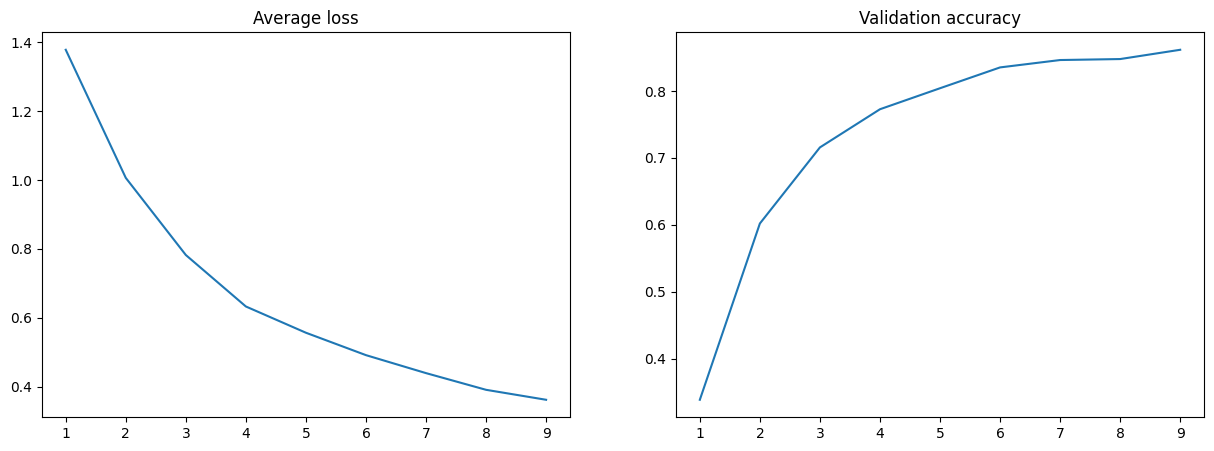

In [7]:
# ==================== Plot Results ====================
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
axs[0].plot(np.arange(1, len(avg_test_loss)+1), np.array(avg_test_loss))
axs[0].set_title("Average loss")

axs[1].plot(np.arange(1, len(valid_accs)+1), np.array(valid_accs))
axs[1].set_title("Validation accuracy")
plt.show()




In [8]:
# ==================== Test Evaluation ====================

correct = 0
total = 0

for id in range(NUM_CLIENTS):
    shared_weights = {k: v for k, v in current_weights.items() 
                        if not any(p in k for p in PERSONALIZED)}
    client_net = clients[id].net
    client_net.load_state_dict(shared_weights, strict=False)
    client_net.to(device)
    client_net.eval()

    with torch.no_grad():
        for (sounds, labels) in testloader:
            sounds, labels = sounds.to(device), labels.to(device)
            outputs = client_net(sounds)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        client_net.to('cpu')


print(f'Accuracy on test set: {100 * correct // total} %')

# Per-class accuracy
correct_pred = {classname: 0 for classname in digits}
total_pred = {classname: 0 for classname in digits}

for id in range(NUM_CLIENTS):
    shared_weights = {k: v for k, v in current_weights.items() 
                        if not any(p in k for p in PERSONALIZED)}
    client_net = clients[id].net
    client_net.load_state_dict(shared_weights, strict=False)
    client_net.to(device)
    client_net.eval()

    with torch.no_grad():
        for (sounds, labels) in testloader:
            sounds, labels = sounds.to(device), labels.to(device)
            outputs = client_net(sounds)
            _, predicted = torch.max(outputs, 1)
            for label, prediction in zip(labels, predicted):
                if label == prediction:
                    correct_pred[digits[label]] += 1
                total_pred[digits[label]] += 1

        client_net.to('cpu')


        
        

for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for digit {classname}: {accuracy:.1f} %')

Accuracy on test set: 89 %
Accuracy for digit 0: 93.7 %
Accuracy for digit 1: 93.9 %
Accuracy for digit 2: 92.8 %
Accuracy for digit 3: 70.6 %
Accuracy for digit 4: 96.3 %
Accuracy for digit 5: 91.2 %
Accuracy for digit 6: 80.6 %
Accuracy for digit 7: 90.2 %
Accuracy for digit 8: 93.9 %
Accuracy for digit 9: 90.7 %


In [ ]:
import matplotlib.pyplot as plt

digits = list(correct_pred.keys())
accuracies = [100 * float(correct_pred[c]) / total_pred[c] for c in digits]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(digits, accuracies, color='steelblue')

ax.set_xlabel('Digit')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy per digits')
ax.set_xticks(digits)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()